In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from myutils import display_ppm_image,convert_jfif_to_ppm,predict_traffic_sign_all,ppm_to_tensor_tf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from GTSRB_utils import GTSRB_CLASSES, predict_traffic_sign, create_subset_loader, load_ppm_image

In [2]:
from tensorflow.keras.models import load_model
model = load_model("TrafficSigns_EfficientNetB1.keras")

In [65]:
import tensorflow as tf
import numpy as np
from scipy.fftpack import dct, idct

def dct2(a):
    """Compute the 2D DCT (type II) with orthogonal normalization."""
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    """Compute the 2D Inverse DCT with orthogonal normalization."""
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

import tensorflow as tf
import numpy as np
from scipy.fftpack import dct, idct

def dct2(a):
    """Compute the 2D DCT (type II) with orthogonal normalization."""
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    """Compute the 2D Inverse DCT with orthogonal normalization."""
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

def preprocess_image_dct_tensor(image_tensor, low_freq_fraction=1/8):
    """
    Converts an image tensor into the DCT domain and selects low-frequency components.

    Parameters:
        image_tensor (tf.Tensor): Image tensor of shape (H, W, C) or (1, H, W, C)
        low_freq_fraction (float): Fraction of low-frequency coefficients to select

    Returns:
        dct_coeffs_tensor (tf.Tensor): DCT coefficients with same shape as image
        mask (np.array): Boolean mask of shape (H, W, 1) for low-frequency components
    """
    # Ensure the tensor is concrete (EagerTensor)
    image_tensor = tf.convert_to_tensor(image_tensor)

    # Remove batch dimension if present
    if len(image_tensor.shape) == 4 and image_tensor.shape[0] == 1:
        image_tensor = tf.squeeze(image_tensor, axis=0)

    # Get the image as NumPy array
    image_np = image_tensor.numpy()  # This will now work

    H, W, C = image_np.shape
    dct_coeffs = np.empty_like(image_np, dtype=np.float32)

    # Apply 2D DCT for each channel
    for c in range(C):
        dct_coeffs[..., c] = dct2(image_np[..., c])

    # Define the low-frequency square block size
    block_height = int(np.ceil(H * np.sqrt(low_freq_fraction)))
    block_width = int(np.ceil(W * np.sqrt(low_freq_fraction)))

    # Create a 2D low-frequency mask (top-left block)
    mask_2d = np.zeros((H, W), dtype=bool)
    mask_2d[:block_height, :block_width] = True

    # Expand the 2D mask to 3D for broadcasting across channels
    mask = np.expand_dims(mask_2d, axis=-1)  # Shape (H, W, 1)

    # Convert DCT coefficients to a TensorFlow tensor
    dct_coeffs_tensor = tf.convert_to_tensor(dct_coeffs, dtype=tf.float32)

    return dct_coeffs_tensor, mask



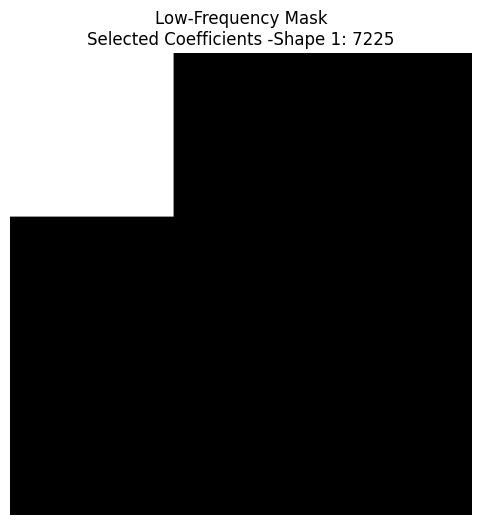

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of low-frequency coefficients (True values)
num_low_freq = np.sum(low_freq_mask)

# Display the mask with the count
plt.figure(figsize=(6, 6))
plt.imshow(low_freq_mask, cmap='gray')
plt.title(f'Low-Frequency Mask\nSelected Coefficients -Shape 1: {num_low_freq}')
plt.axis('off')
plt.show()


In [3]:
import tensorflow as tf
from PIL import Image
import numpy as np

def preprocess_image(image_path, target_size=(240, 240)):
    """
    Loads and preprocesses an image for EfficientNetB1 model input.

    Args:
        image_path (str): Path to the image file.
        target_size (tuple): The target size for resizing (default is 240x240 for EfficientNetB1).

    Returns:
        tf.Tensor: A preprocessed image tensor of shape (1, 240, 240, 3) with dtype float32.
    """
    # Load and resize image
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.BILINEAR)

    # Convert to numpy and expand dimensions to add batch axis
    img_array = np.array(img, dtype=np.float32)  # stays in [0, 255]
    img_tensor = tf.convert_to_tensor(img_array)
    img_tensor = tf.expand_dims(img_tensor, axis=0)  # shape: (1, 240, 240, 3)

    return img_tensor


In [4]:
import scipy.fftpack

def rgb_image_to_dct(image_tensor):
    """
    Applies 2D DCT to each channel of an image.

    Args:
        image_tensor: A 4D float32 tensor of shape (1, H, W, 3), range [0, 255]

    Returns:
        dct_coeffs: A numpy array of the same shape (1, H, W, 3), in DCT space
    """
    image_np = image_tensor.numpy().squeeze(0)  # shape: (H, W, 3)
    H, W, C = image_np.shape
    dct_coeffs = np.zeros_like(image_np)

    # Apply 2D DCT on each channel
    for c in range(C):
        dct_coeffs[:, :, c] = scipy.fftpack.dct(
            scipy.fftpack.dct(image_np[:, :, c].T, norm='ortho').T, norm='ortho'
        )

    # Add batch dimension back
    dct_coeffs = np.expand_dims(dct_coeffs, axis=0)
    return dct_coeffs


In [5]:
def dct_to_rgb_image(dct_coeffs):
    """
    Applies 2D inverse DCT to each channel of an image.

    Args:
        dct_coeffs: A 4D numpy array of shape (1, H, W, 3)

    Returns:
        image_tensor: A float32 tensor of shape (1, H, W, 3) in pixel space
    """
    dct_np = dct_coeffs.squeeze(0)  # shape: (H, W, 3)
    H, W, C = dct_np.shape
    image_np = np.zeros_like(dct_np)

    for c in range(C):
        image_np[:, :, c] = scipy.fftpack.idct(
            scipy.fftpack.idct(dct_np[:, :, c].T, norm='ortho').T, norm='ortho'
        )

    # Clip and reshape
    image_np = np.clip(image_np, 0, 255)
    image_tensor = tf.convert_to_tensor(np.expand_dims(image_np, axis=0), dtype=tf.float32)
    return image_tensor


In [7]:
image_path="No.jfif"
image_tensor2 = preprocess_image(image_path)          # shape (1, 240, 240, 3)
#dct_coeffs = rgb_image_to_dct(image_tensor)          # shape (1, 240, 240, 3)

In [8]:
import numpy as np
import tensorflow as tf
import scipy.fftpack

def simba_dct_attack(image_tensor, true_label, model, num_iters=2000, epsilon=0.2, print_every=10, initial_freq_frac=1/8):
    """
    Performs the SimBA-DCT adversarial attack.

    Args:
        image_tensor: Tensor of shape (1, H, W, 3) in [0, 255]
        true_label: Integer, correct label of the image
        model: Black-box model to query
        num_iters: Max number of queries
        epsilon: Step size in DCT space
        print_every: Print frequency
        initial_freq_frac: Fraction of lowest DCT frequencies to use initially

    Returns:
        adv_tensor: Final adversarial image in pixel space
    """
    epsilon_scaled = epsilon * 255

    # --- Step 1: Get DCT Coefficients of the image ---
    dct_image = rgb_image_to_dct(image_tensor)      # shape: (1, H, W, 3)
    H, W, C = dct_image.shape[1:]

    # --- Step 2: Initialize delta ---
    delta = np.zeros_like(dct_image)

    # --- Step 3: Get initial prediction ---
    pred = model.predict(image_tensor)
    true_prob = pred[0][true_label]
    print("Initial true class probability: {:.4f}".format(true_prob))

    # --- Step 4: Prepare list of DCT basis directions ---
    total_freqs = H * W * C
    num_initial_freqs = int(total_freqs * initial_freq_frac)

    # All frequency indices as (row, col, channel) tuples
    all_indices = [(i // (W * C), (i // C) % W, i % C) for i in range(total_freqs)]
    np.random.shuffle(all_indices)
    Q_dct = all_indices[:num_initial_freqs]
    current_pointer = num_initial_freqs

    queries = 0
    for i in range(num_iters):
        if len(Q_dct) == 0:
            # Exhausted current directions, add more frequencies
            additional = int(total_freqs / 32)
            next_indices = all_indices[current_pointer : current_pointer + additional]
            if not next_indices:
                print("No more directions to explore.")
                break
            Q_dct.extend(next_indices)
            current_pointer += additional

        # --- Step 5: Sample direction q ---
        row, col, channel = Q_dct.pop(np.random.randint(len(Q_dct)))

        # Create perturbation in DCT space
        perturb = np.zeros_like(delta)
        perturb[0, row, col, channel] = epsilon_scaled

        # --- Step 6: Test +epsilon ---
        dct_plus = dct_image + delta + perturb
        x_plus = dct_to_rgb_image(dct_plus)
        prob_plus = model.predict(x_plus)
        queries += 1
        p_plus = prob_plus[0][true_label]

        # --- Step 7: Test -epsilon ---
        dct_minus = dct_image + delta - perturb
        x_minus = dct_to_rgb_image(dct_minus)
        prob_minus = model.predict(x_minus)
        queries += 1
        p_minus = prob_minus[0][true_label]

        # --- Step 8: Decide best update ---
        if p_plus < true_prob:
            delta += perturb
            true_prob = p_plus
            if i % print_every == 0:
                print(f"Iter {i}: +ε at ({row},{col},{channel}), new_prob={p_plus:.6f}")
        elif p_minus < true_prob:
            delta -= perturb
            true_prob = p_minus
            if i % print_every == 0:
                print(f"Iter {i}: -ε at ({row},{col},{channel}), new_prob={p_minus:.6f}")
        elif i % print_every == 0:
            print(f"Iter {i}: No improvement at ({row},{col},{channel}), prob={true_prob:.6f}")

        # Stop if attack is successful (label flipped)
        final_pred = np.argmax(model.predict(dct_to_rgb_image(dct_image + delta))[0])
        queries += 1
        if final_pred != true_label:
            print(f"Attack succeeded at iteration {i} after {queries} queries!")
            break

    adv_image = dct_to_rgb_image(dct_image + delta)
    return adv_image


In [9]:
predict_traffic_sign_all(image_tensor2, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0009
Class 8 (Speed limit 120): 0.0001
Class 9 (No passing): 0.3813
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0003
Class 13 (Yield): 0.0375
Class 14 (Stop): 0.0012
Class 15 (No vehicles): 0.0001
Class 16 (Vehicles over 3.5 tons prohibited): 0.0479
Class 17 (No entry): 0.0026
Class 18 (General caution): 0.0007
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0001
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.1456
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(9)

In [11]:

adv_image = simba_dct_attack(image_tensor2, true_label=9, model=model, epsilon=0.2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
Initial true class probability: 0.3813
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Iter 0: -ε at (53,239,0), new_prob=0.380932
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
Attack succeeded at iteration 1 after 6 queries!


In [12]:
predict_traffic_sign_all(adv_image, model, GTSRB_CLASSES)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0009
Class 8 (Speed limit 120): 0.0001
Class 9 (No passing): 0.3792
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0003
Class 13 (Yield): 0.0375
Class 14 (Stop): 0.0012
Class 15 (No vehicles): 0.0001
Class 16 (Vehicles over 3.5 tons prohibited): 0.0478
Class 17 (No entry): 0.0026
Class 18 (General caution): 0.0007
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0001
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.1453
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (T

np.int64(41)

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def show_tensor_image(tensor_img, title=None):
    """
    Displays a TensorFlow image tensor.

    Parameters:
        tensor_img: A tensor of shape (H, W, C) or (1, H, W, C)
        title: Optional title for the image
    """
    # Remove batch dimension if present
    if tensor_img.ndim == 4:
        tensor_img = tensor_img[0]

    # Convert to uint8 if values are in [0, 255]
    img = tensor_img.numpy().astype(np.uint8)

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


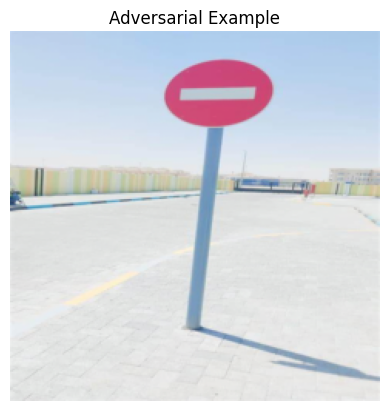

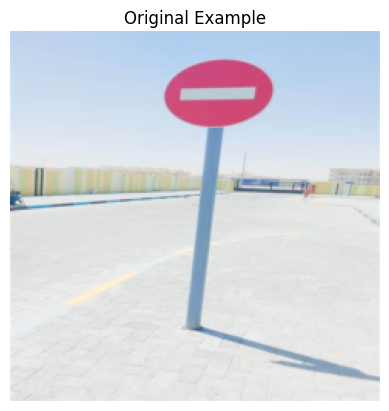

In [15]:
# Assuming `adv_tensor` is your adversarial image tensor
show_tensor_image(adv_image, title="Adversarial Example")
show_tensor_image(image_tensor2, title="Original Example")

In [16]:
second_image_path="Novehicle.jfif"
image_tensor3 = preprocess_image(second_image_path)

In [17]:
predict_traffic_sign_all(image_tensor3, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0002
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.1539
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0001
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0000
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.8433
Class 17 (No entry): 0.0000
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(16)

In [20]:
adv_image = simba_dct_attack(image_tensor3, true_label=16, model=model, epsilon=0.2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
Initial true class probability: 0.8433
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
Iter 0: No improvement at (179,77,1), prob=0.843291
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
1/1 ━━━━━━━━━━━━━━

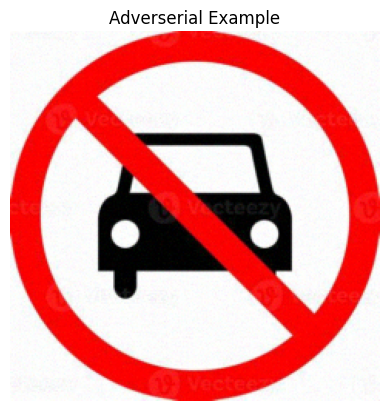

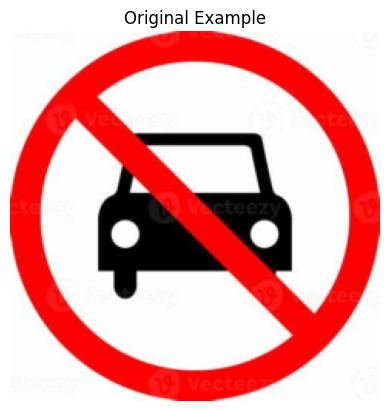

In [22]:
show_tensor_image(adv_image , title="Adverserial Example")

show_tensor_image(image_tensor3 , title="Original Example")

In [23]:
predict_traffic_sign_all(adv_image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0003
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0002
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.4982
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0002
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0000
Class 15 (No vehicles): 0.0001
Class 16 (Vehicles over 3.5 tons prohibited): 0.4978
Class 17 (No entry): 0.0000
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(7)